In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('/cta/users/guneyn23')
OUT = BASE / 'relative_repair/window_mean_relative_all_regions'
OUT.mkdir(parents=True, exist_ok=True)

N_WINDOWS = 400
TIMES = ['15m', '30m', '1h', '4h', '8h']
REGIONS = ['ATAC', 'H3K9me3', 'H3K27me3']

REFERENCE = {
    'ATAC': {
        'CPD': [BASE/'rpkm/CPD_rpkm/atac_rpkm/real_damage_rpkm.bed', BASE/'rpkm/CPD_rpkm/atac_rpkm/sim_damage_rpkm.bed'],
        '64': [BASE/'rpkm/64_rpkm/ATAC_real_64_rpkm.bed', BASE/'rpkm/64_rpkm/ATAC_simulated_64_rpkm.bed'],
    },
    'H3K9me3': {
        'CPD': [BASE/'rpkm/CPD_rpkm/close_rpkm/H3k9me3_real_rpkm.bed', BASE/'rpkm/CPD_rpkm/close_rpkm/H3k9me3_sim_rpkm.bed'],
        '64': [BASE/'rpkm/64_rpkm/H3K9me3_real_64_rpkm.bed', BASE/'rpkm/64_rpkm/H3K9me3_simulated_64_rpkm.bed'],
    },
    'H3K27me3': {
        'CPD': [BASE/'rpkm/CPD_rpkm/close_rpkm/H3k27me3_real_rpkm.bed', BASE/'rpkm/CPD_rpkm/close_rpkm/H3k27me3_sim_rpkm.bed'],
        '64': [BASE/'rpkm/64_rpkm/H3K27me3_real_64_rpkm.bed', BASE/'rpkm/64_rpkm/H3K27me3_simulated_64_rpkm.bed'],
    },
}

STEMS = {
    ('CPD','15m'): 'R3Hela_15mCPD_TAGCTT_S2_hg38_primary_assembly_DS',
    ('CPD','30m'): 'R3Hela_30mCPD_GGCTAC_S8_hg38_primary_assembly_DS',
    ('CPD','1h'): 'R3Hela_1hCPD_CTTGTA_S4_hg38_primary_assembly_DS',
    ('CPD','4h'): 'R3Hela_4hCPD_AGTCAA_S10_hg38_primary_assembly_DS',
    ('CPD','8h'): 'R3Hela_8hCPD_AGTTCC_S12_hg38_primary_assembly_DS',
    ('64','15m'): 'R3Hela_15m64_TTAGGC_S1_hg38_primary_assembly_DS',
    ('64','30m'): 'R3Hela_30m64_TGACCA_S7_hg38_primary_assembly_DS',
    ('64','1h'): 'R3Hela_1h64_ACAGTG_S3_hg38_primary_assembly_DS',
    ('64','4h'): 'R3Hela_4h64_GCCAAT_S9_hg38_primary_assembly_DS',
    ('64','8h'): 'R3Hela_8h64_CAGATC_S11_hg38_primary_assembly_DS',
}

In [15]:
def timepoint_file(region, damage, time, simulated=False):
    stem = STEMS[(damage, time)] + ('_sim' if simulated else '')
    if region == 'ATAC':
        folder = BASE / 'relative_repair/rpkm/noUV_atac_damage_all'
        return folder / f'{stem}_noUV_ATAC_400windows_rpkm.bed'
    folder = BASE / 'peak_center_20kb/rpkm' / region
    return folder / f'{stem}_{region}_400windows_rpkm.bed'


def window_mean(path):
    data = pd.read_csv(path, sep='\t', header=None)
    data['rpkm'] = data.iloc[:, -1]
    data['window'] = (data.index % N_WINDOWS) + 1
    return data.groupby('window')['rpkm'].mean()


In [ ]:
results = []

for region in REGIONS:
    for damage in ['CPD', '64']:
        mean_1m_real = window_mean(REFERENCE[region][damage][0])
        mean_1m_sim = window_mean(REFERENCE[region][damage][1])

        for time in TIMES:
            mean_time_real = window_mean(timepoint_file(region, damage, time, simulated=False))
            mean_time_sim = window_mean(timepoint_file(region, damage, time, simulated=True))

            result = pd.DataFrame({
                'region': region,
                'damage': damage,
                'time': time,
                'window': mean_1m_real.index,
                'mean_1m_real': mean_1m_real.values,
                'mean_time_real': mean_time_real.values,
                'mean_1m_sim': mean_1m_sim.values,
                'mean_time_sim': mean_time_sim.values,
            })

            result['relative_real'] = (result['mean_1m_real'] - result['mean_time_real']) / result['mean_1m_real']
            result['relative_sim'] = (result['mean_1m_sim'] - result['mean_time_sim']) / result['mean_1m_sim']
            result['relative_real_div_sim'] = result['relative_real'] / result['relative_sim']

            result.to_csv(OUT/f'{region}_{damage}_{time}.tsv', sep='\t', index=False)
            results.append(result)

summary = pd.concat(results, ignore_index=True)
summary.to_csv(OUT/'window_mean_relative_results.tsv', sep='\t', index=False)
summary.head()

KeyboardInterrupt: 

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path(
    "/cta/users/guneyn23/relative_repair/window_mean_relative_all_regions"
)

summary = pd.read_csv(
    OUT / "window_mean_relative_results.tsv",
    sep="\t",
    dtype={"damage": str}
)



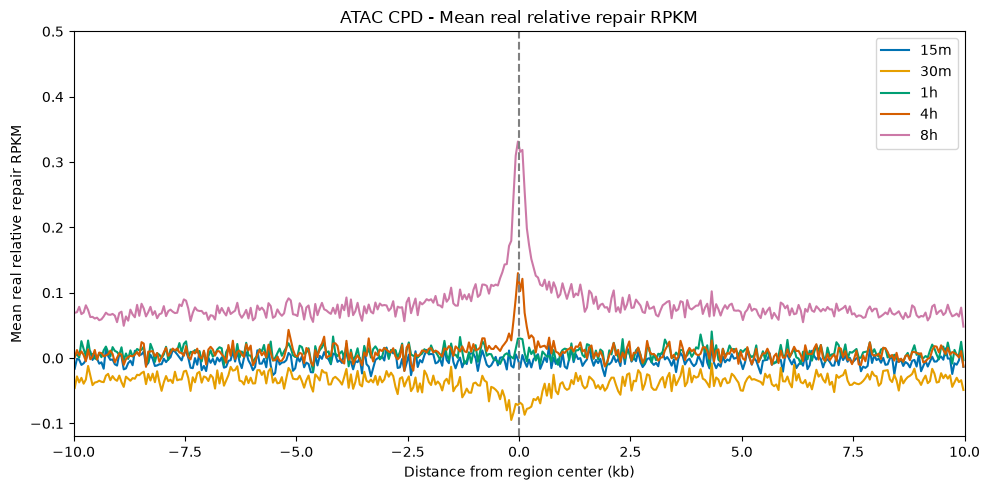

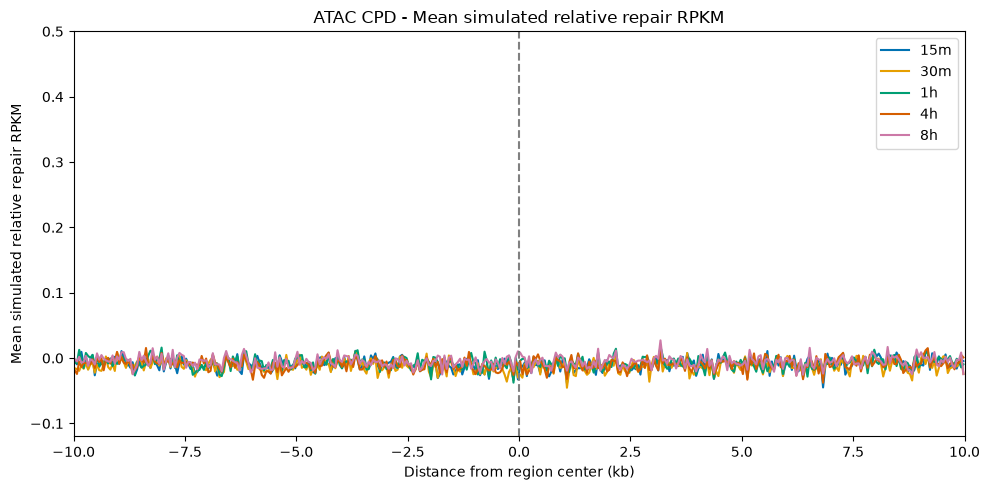

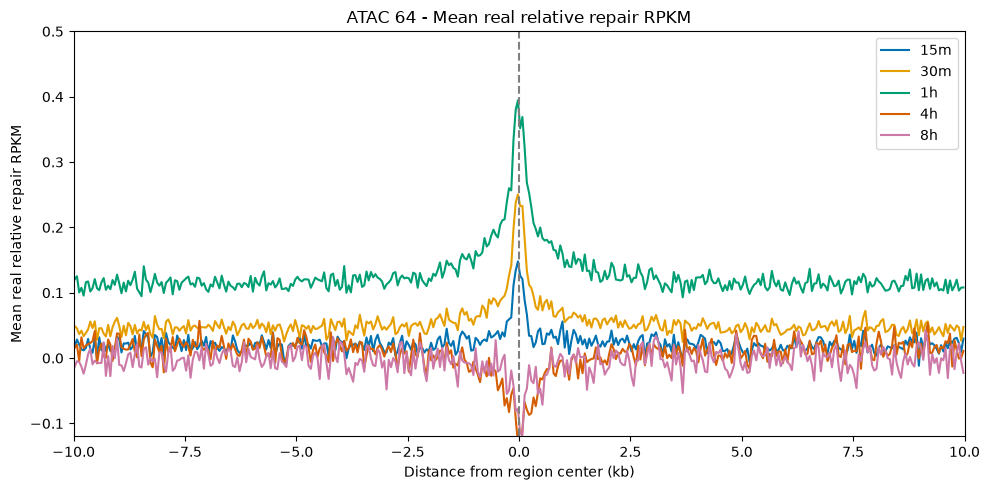

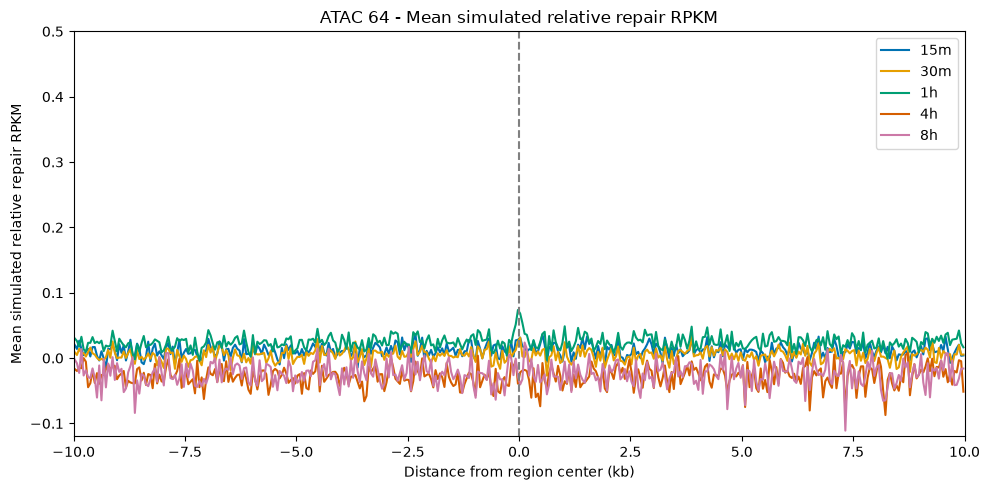

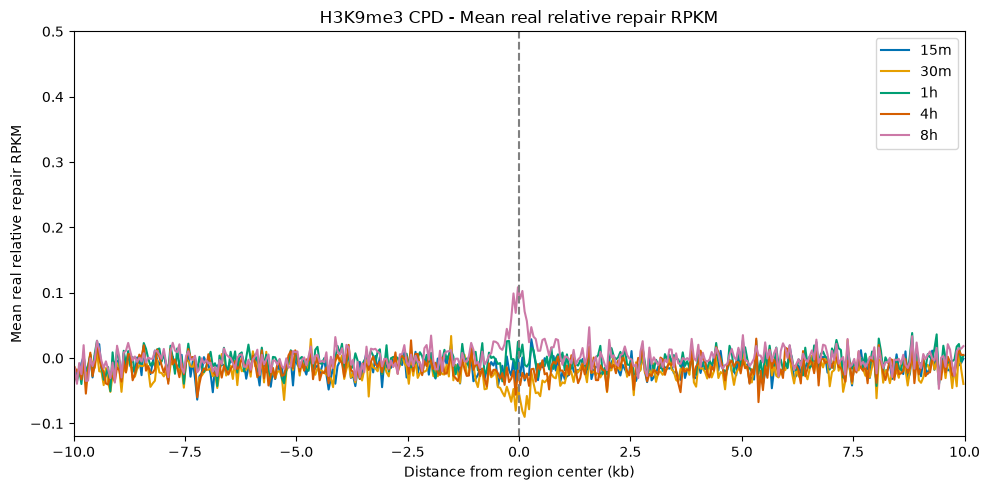

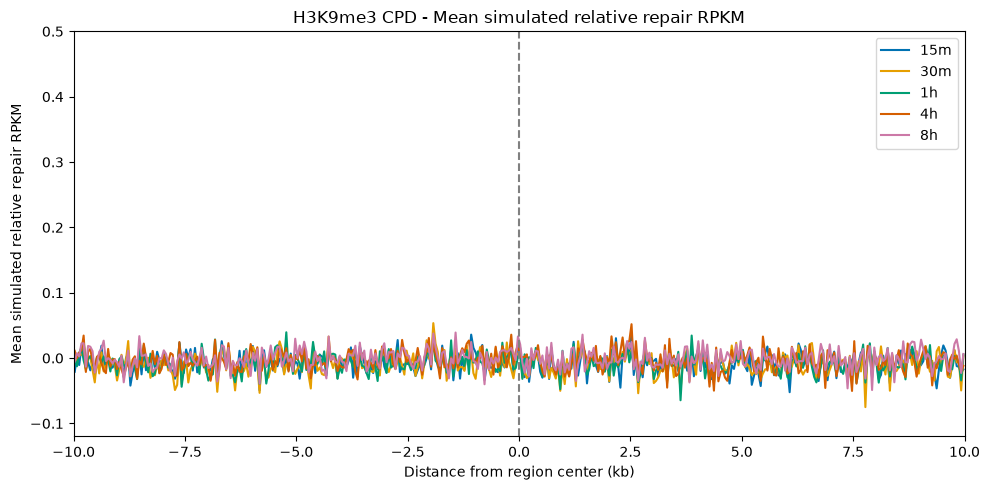

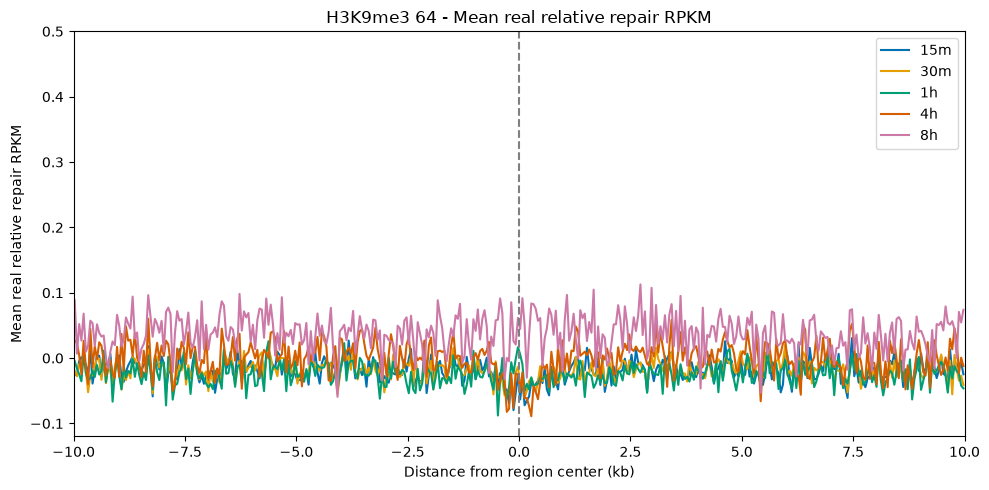

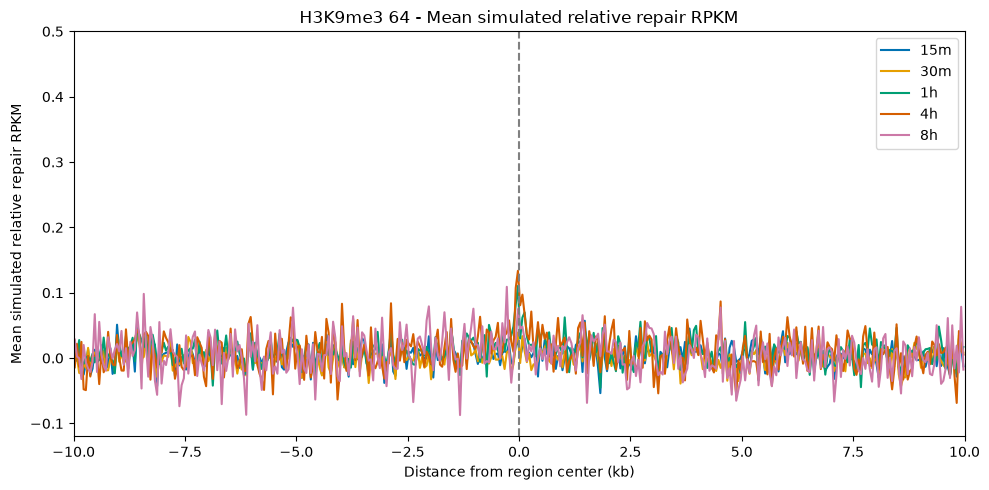

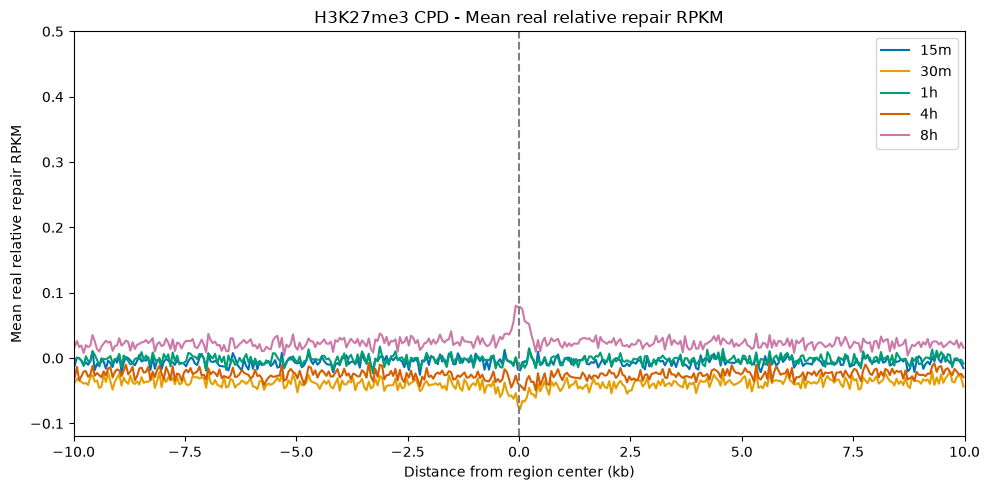

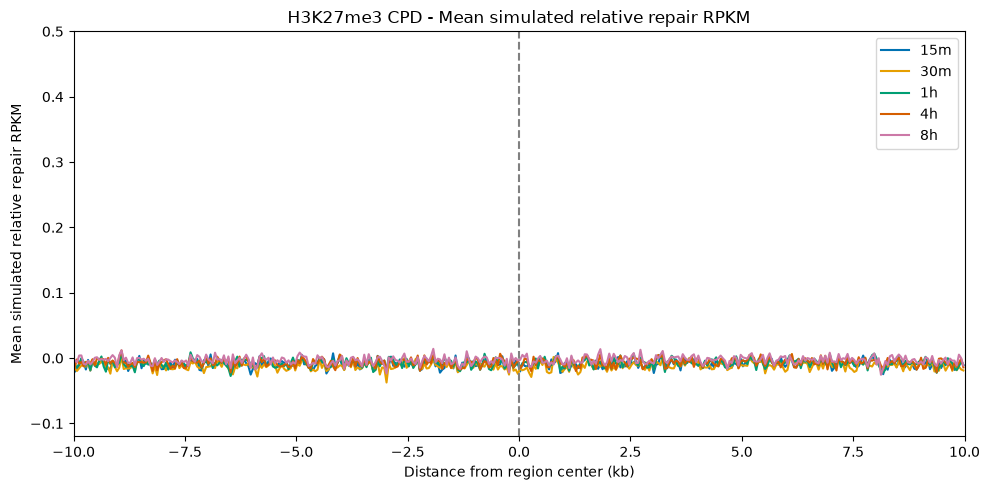

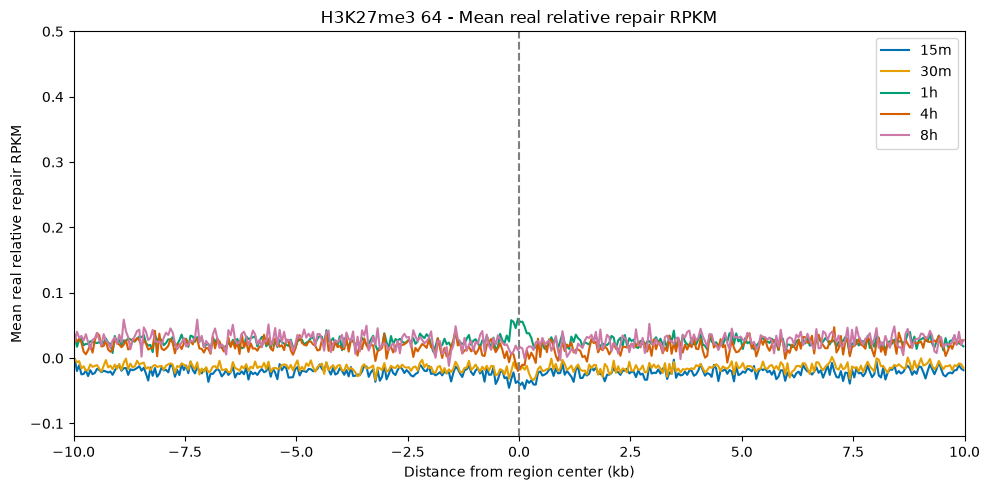

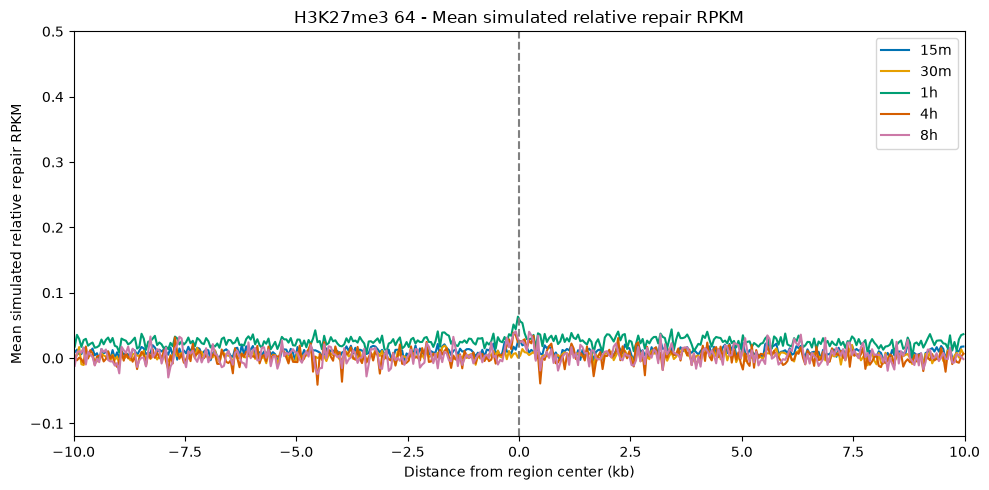

In [20]:

for region in REGIONS:
    for damage in ['CPD', '64']:
        selected = summary[
            (summary['region'] == region)
            & (summary['damage'] == damage)
        ]

        for column, ylabel, suffix in [
            ('relative_real', 'Mean real relative repair RPKM', 'relative_real'),
            ('relative_sim', 'Mean simulated relative repair RPKM', 'relative_sim'),
            
        ]:
            fig, ax = plt.subplots(figsize=(10, 5))

            for time in TIMES:
                data = selected[selected['time'] == time]
                ax.plot(x, data[column], label=time, color=colors[time])

            ax.axvline(0, color='gray', linestyle='--')
            ax.set_xlim(-10, 10)
            ax.set_ylim(-0.12, 0.5)
            ax.set_xlabel('Distance from region center (kb)')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{region} {damage} - {ylabel}')
            ax.legend()
            fig.tight_layout()
            fig.savefig(OUT/f'{region}_{damage}_{suffix}.png', dpi=300)
            plt.show()